# Notebook 2: Deep Learning Methods for Non-Concave Utility Maximization

**Reference**: Dai, Kou, Qian & Wan (2019) — solved with HJB finite differences  
**This notebook**: Four neural network approaches vs. the FD baseline

| Method | Core idea |
|--------|-----------|
| Deep BSDE | Parameterise policy π(t,w;θ) per time-step; minimise −E[U(W_T)] |
| PINN | Parameterise V(t,w;θ) and penalise HJB residual |
| Actor-Critic RL | Separate policy + value networks, advantage policy gradient |
| LSTM / Transformer | Sequence models trained on FD-optimal trajectories |

Two utility functions are studied: **goal-reaching** U(w)=𝟙_{w≥1} and **aspiration** utility.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings('ignore')

# ── PyTorch (required) ─────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.distributions import Beta
    # Device: MPS (Apple Silicon) > CUDA > CPU
    if torch.backends.mps.is_available():
        DEVICE = torch.device("mps")
    elif torch.cuda.is_available():
        DEVICE = torch.device("cuda")
    else:
        DEVICE = torch.device("cpu")
    print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")
except ImportError:
    raise ImportError("PyTorch is required. Install with: pip install torch")

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})


PyTorch 2.8.0  |  device: mps


## 0. Shared Utilities — Parameters, Market Simulation, FD Baseline

In [23]:
# ── Market parameters (goal-reaching case) ────────────────────────────────
MU, R, SIGMA = 0.15, 0.07, 0.3
ETA   = MU - R
T_HOR = 1.0
D, U  = 0.0, 1.0    # portfolio constraint [d, u]
GOAL  = 1.0

# Utility functions
def goal_utility_np(w):
    return (np.asarray(w) >= GOAL).astype(float)

def goal_utility_torch(w):
    return (w >= GOAL).float()

def aspiration_utility_np(w, p=0.5, c1=1.2, c2=0.0, R=1.0):
    w = np.asarray(w, float)
    return np.where(w < R, w**p / p, c1 * w**p / p + c2)

def aspiration_utility_torch(w, p=0.5, c1=1.2, c2=0.0, R=1.0):
    return torch.where(w < R, w**p / p, c1 * w**p / p + c2)

# Normal CDF (numpy)
def Phi(x):
    x = np.asarray(x, float)
    neg = x < 0
    xa  = np.abs(x)
    t_  = 1.0 / (1.0 + 0.2316419 * xa)
    poly = t_ * (0.319381530 + t_ * (-0.356563782 + t_ * (1.781477937
            + t_ * (-1.821255978 + t_ * 1.330274429))))
    p = 1.0 - np.exp(-0.5 * xa**2) / np.sqrt(2 * np.pi) * poly
    return np.clip(np.where(neg, 1 - p, p), 0, 1)

# Browne analytical solution
def browne_V(w, t, T=T_HOR):
    tau = max(T - t, 1e-10)
    z = np.log(np.maximum(w, 1e-8)) / (SIGMA * np.sqrt(tau))
    return Phi(z)

def browne_pi(w, t, T=T_HOR):
    tau = max(T - t, 1e-10)
    return np.log(np.maximum(np.asarray(w), 1e-8)) / (SIGMA * np.sqrt(tau))

print("Parameters and utilities defined.")


Parameters and utilities defined.


In [24]:
# ── Compact FD Solver (monotone implicit baseline) ─────────────────────────
def fd_solve(mu=MU, r=R, sigma=SIGMA, T=T_HOR, A=3.0, Nw=120, Nt=120,
             utility_fn=None, d=D, u=U):
    """
    Monotone implicit FD solver (backward Euler + policy iteration + Thomas algorithm).
    Tridiagonal coefficients are unconditionally monotone: row sum = 1 always.
    Returns (w_grid, V_t0, Pi_t0).
    """
    if utility_fn is None:
        utility_fn = goal_utility_np
    eta  = mu - r
    sig2 = sigma**2
    w    = np.linspace(0, A, Nw + 1)
    dw   = A / Nw
    dt   = T / Nt
    UB   = float(utility_fn(np.array([0.0])).flat[0])
    UA   = float(utility_fn(np.array([A])).flat[0])

    def _thomas(a, b, c, rhs):
        """Thomas algorithm for tridiagonal system."""
        n = len(b)
        c2, d2, x = np.zeros(n), np.zeros(n), np.zeros(n)
        c2[0] = c[0] / b[0]; d2[0] = rhs[0] / b[0]
        for k in range(1, n):
            den = b[k] - a[k] * c2[k-1]
            c2[k] = c[k] / den if k < n-1 else 0.0
            d2[k] = (rhs[k] - a[k] * d2[k-1]) / den
        x[-1] = d2[-1]
        for k in range(n-2, -1, -1):
            x[k] = d2[k] - c2[k] * x[k+1]
        return x

    V   = utility_fn(w).copy().astype(float)
    Pi  = np.zeros(Nw + 1)

    for _ in range(Nt):
        V_old = V.copy()
        pi_n  = Pi.copy()

        for _iter in range(30):   # policy iteration
            pi_old = pi_n.copy()
            N_int = Nw - 1
            a_s = np.zeros(N_int)
            b_m = np.zeros(N_int)
            c_s = np.zeros(N_int)
            rhs = np.zeros(N_int)

            for idx in range(N_int):
                i  = idx + 1
                wi = w[i]
                pi = pi_n[i]

                a2    = 0.5 * pi**2 * wi**2 * sig2
                # Monotone upwind split: Ap>=0 (forward), Am<=0 (backward)
                A_adv = pi * wi * eta
                Ap    = max(A_adv, 0.0) / dw
                Am    = min(A_adv, 0.0) / dw

                # Row-sum-1 implicit coefficients (unconditionally monotone)
                a_s[idx] = -dt * (a2/dw**2 - Am)
                b_m[idx] =  1.0 + dt * (2*a2/dw**2 + Ap - Am)
                c_s[idx] = -dt * (a2/dw**2 + Ap)
                rhs[idx] = V_old[i]

            # Boundary adjustments
            rhs[0]      -= a_s[0]      * UB; a_s[0]      = 0.0
            rhs[N_int-1]-= c_s[N_int-1]* UA; c_s[N_int-1]= 0.0

            V_int = _thomas(a_s, b_m, c_s, rhs)
            V_new = np.empty(Nw + 1)
            V_new[0] = UB; V_new[Nw] = UA; V_new[1:Nw] = V_int

            # Update optimal pi (three-case for concave/convex/linear Hamiltonian)
            for i in range(1, Nw):
                wi  = w[i]
                Vww = (V_new[i+1] - 2*V_new[i] + V_new[i-1]) / dw**2
                Vw  = (V_new[i+1] - V_new[i-1]) / (2*dw)
                if Vww < -1e-12:
                    pi_n[i] = float(np.clip(-wi*eta*Vw / (wi**2*sig2*Vww), d, u))
                elif Vww > 1e-12:
                    f_d = 0.5*d**2*wi**2*sig2*Vww + d*wi*eta*Vw
                    f_u = 0.5*u**2*wi**2*sig2*Vww + u*wi*eta*Vw
                    pi_n[i] = u if f_u >= f_d else d
                else:
                    pi_n[i] = u if eta*Vw > 0 else d

            if np.max(np.abs(pi_n - pi_old)) < 1e-8:
                break

        V  = V_new
        Pi = pi_n.copy()

    return w, V, Pi

print("Compact FD solver defined. Computing baseline...")
t0 = time.time()
w_fd, V_fd, Pi_fd = fd_solve()
print(f"FD baseline done in {time.time()-t0:.2f}s")
print(f"  V(0, 0.5) = {np.interp(0.5, w_fd, V_fd):.4f}  (expected ~0.03)")
print(f"  V(0, 0.9) = {np.interp(0.9, w_fd, V_fd):.4f}  (expected ~0.71)")


Compact FD solver defined. Computing baseline...
FD baseline done in 0.85s
  V(0, 0.5) = 0.0301  (expected ~0.03)
  V(0, 0.9) = 0.7556  (expected ~0.71)


## 1. Method 1 — Deep BSDE

**Idea** (Han, Jentzen & E, 2018):  
Parameterise the portfolio weight at each time step as a neural network $\pi_k(W_k;\theta_k)$.  
Simulate $M$ wealth paths forward, compute terminal utility, back-propagate through the path.

$$\mathcal{L}(\theta) = -\mathbb{E}[U(W_T)]$$

Network architecture per time step: $w \to [64] \to [64] \to \sigma(\cdot)\times(u-d)+d$


Training Deep BSDE...
  iter  300 | loss -0.7323 | lr 3.00e-03
  iter  600 | loss -0.7355 | lr 1.50e-03
  iter  900 | loss -0.7324 | lr 1.50e-03
  iter 1200 | loss -0.7347 | lr 7.50e-04
  iter 1500 | loss -0.7313 | lr 3.75e-04
Deep BSDE trained in 67.9s


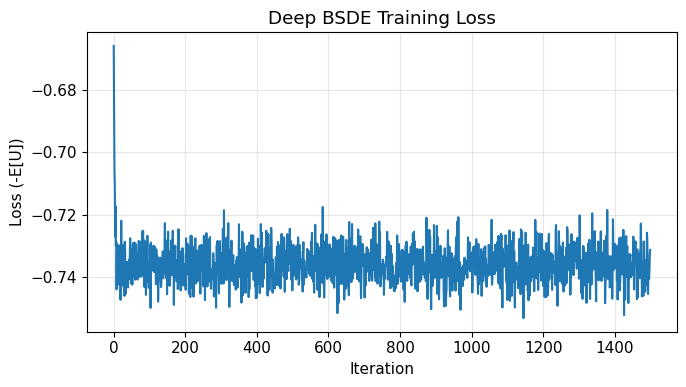

In [25]:
# ── Deep BSDE ─────────────────────────────────────────────────────────────
class StepNet(nn.Module):
    """Small MLP: wealth w (scalar) -> portfolio weight pi in [D, U]."""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )
    def forward(self, w):
        return self.net(w) * (U - D) + D   # scale to [D, U]


class DeepBSDE(nn.Module):
    """
    Deep BSDE model: one StepNet per time step.
    Simulates wealth forward and computes -E[U(W_T)].
    """
    def __init__(self, n_steps=40, hidden=64):
        super().__init__()
        self.n_steps = n_steps
        self.dt      = T_HOR / n_steps
        self.nets    = nn.ModuleList([StepNet(hidden) for _ in range(n_steps)])

    def forward(self, w0, utility_fn, n_paths=2048):
        """Simulate n_paths wealth paths and return mean utility."""
        dt     = self.dt
        W      = w0.expand(n_paths, 1).clone()   # (n_paths, 1)
        sig_sq = SIGMA * np.sqrt(dt)

        for k, net in enumerate(self.nets):
            pi  = net(W)                        # (n_paths, 1) in [D,U]
            dB  = torch.randn_like(W) * sig_sq
            dW  = W * pi * (ETA * dt + SIGMA * dB)
            W   = torch.clamp(W + dW, min=1e-6)

        return -utility_fn(W.squeeze()).mean()   # negative expected utility

    def get_policy(self, w_arr):
        """Extract π*(0, w) from step-0 network."""
        self.eval()
        with torch.no_grad():
            w_t = torch.tensor(w_arr, dtype=torch.float32, device=DEVICE).unsqueeze(1)
            return self.nets[0](w_t).squeeze().cpu().numpy()


# ── Training ──────────────────────────────────────────────────────────────
bsde_model = DeepBSDE(n_steps=40, hidden=64).to(DEVICE)
optimizer  = optim.Adam(bsde_model.parameters(), lr=3e-3)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

w0_batch = torch.tensor([[1.0]], dtype=torch.float32, device=DEVICE)
U_SMOOTH  = lambda w: torch.sigmoid((w - GOAL) / 0.05)   # smooth goal approx

n_iter      = 1500
bsde_losses = []

print("Training Deep BSDE...")
t0 = time.time()
for it in range(n_iter):
    optimizer.zero_grad()
    loss = bsde_model(w0_batch, U_SMOOTH, n_paths=2048)
    loss.backward()
    nn.utils.clip_grad_norm_(bsde_model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    bsde_losses.append(loss.item())
    if (it + 1) % 300 == 0:
        print(f"  iter {it+1:4d} | loss {loss.item():.4f} | lr {scheduler.get_last_lr()[0]:.2e}")

t_bsde = time.time() - t0
print(f"Deep BSDE trained in {t_bsde:.1f}s")

# ── Plot training loss ────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(bsde_losses)
plt.xlabel("Iteration"); plt.ylabel("Loss (-E[U])")
plt.title("Deep BSDE Training Loss")
plt.tight_layout(); plt.show()


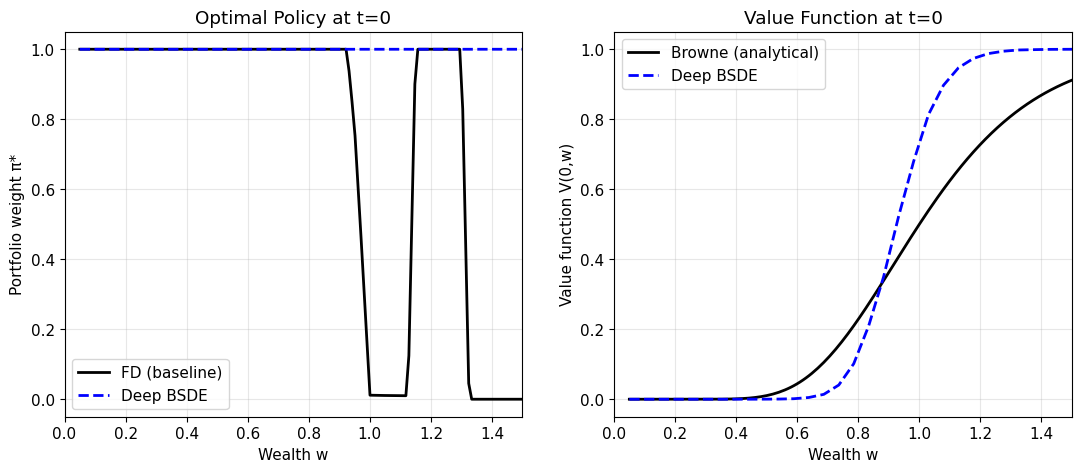

Deep BSDE: training 67.9s


In [26]:
# ── Evaluate Deep BSDE ────────────────────────────────────────────────────
w_test = np.linspace(0.05, 2.0, 200)
pi_bsde = bsde_model.get_policy(w_test.astype(np.float32))
V_browne = browne_V(w_test, 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(w_test, np.clip(np.interp(w_test, w_fd, Pi_fd), 0, 1.5),  'k-',  lw=2, label='FD (baseline)')
axes[0].plot(w_test, np.clip(pi_bsde, D, U),  'b--', lw=2, label='Deep BSDE')
axes[0].set_xlabel('Wealth w'); axes[0].set_ylabel('Portfolio weight π*')
axes[0].set_title('Optimal Policy at t=0')
axes[0].legend(); axes[0].set_xlim(0, 1.5)

axes[1].plot(w_test, V_browne, 'k-', lw=2, label='Browne (analytical)')
# Estimate V(0,w) via Deep BSDE: simulate 5000 paths from each w0
bsde_model.eval()
V_bsde = []
with torch.no_grad():
    for w0_val in w_test[::5]:
        w0_t = torch.tensor([[w0_val]], dtype=torch.float32, device=DEVICE)
        V_est = -bsde_model(w0_t, U_SMOOTH, n_paths=3000).item()
        V_bsde.append(V_est)
axes[1].plot(w_test[::5], np.clip(V_bsde, 0, 1), 'b--', lw=2, label='Deep BSDE')
axes[1].set_xlabel('Wealth w'); axes[1].set_ylabel('Value function V(0,w)')
axes[1].set_title('Value Function at t=0'); axes[1].legend(); axes[1].set_xlim(0, 1.5)

plt.show()
print(f"Deep BSDE: training {t_bsde:.1f}s")


## 2. Method 2 — Physics-Informed Neural Network (PINN)

Parameterise $V(t,w;\theta)$ directly. Enforce the HJB as a collocation loss:
$$\mathcal{L}_{\text{PDE}} = \mathbb{E}\left[\left|\frac{\partial V}{\partial t}
  + \sup_{\pi}\left\{\tfrac{1}{2}\pi^2 w^2\sigma^2 V_{ww} + \pi w\eta V_w\right\}\right|^2\right]$$
plus terminal and boundary losses.


In [27]:
# ── PINN ──────────────────────────────────────────────────────────────────
class PINN(nn.Module):
    """Physics-Informed Neural Network approximating V(t, w)."""
    def __init__(self, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, w):
        # t, w: (N,) tensors -> V: (N,)
        x = torch.stack([t, w], dim=1)
        return self.net(x).squeeze()

pinn = PINN(hidden=64, depth=4).to(DEVICE)
opt_pinn = optim.Adam(pinn.parameters(), lr=1e-3)
sch_pinn = optim.lr_scheduler.CosineAnnealingLR(opt_pinn, T_max=2000)

N_col    = 2048    # collocation points
N_term   = 1024
LAMBDA_T = 10.0    # terminal condition weight
LAMBDA_B = 5.0     # boundary condition weight

pinn_losses = []
print("Training PINN...")
t0 = time.time()

for it in range(2000):
    opt_pinn.zero_grad()

    # ── Collocation points ────────────────────────────────────────────────
    t_col  = torch.rand(N_col, device=DEVICE) * T_HOR
    w_col  = torch.rand(N_col, device=DEVICE) * 2.5 + 0.01
    t_col.requires_grad_(True); w_col.requires_grad_(True)

    V_col = pinn(t_col, w_col)
    Vt    = torch.autograd.grad(V_col.sum(), t_col, create_graph=True)[0]
    Vw    = torch.autograd.grad(V_col.sum(), w_col, create_graph=True)[0]
    Vww   = torch.autograd.grad(Vw.sum(),   w_col, create_graph=True)[0]

    # Optimal π: analytic for quadratic objective (clipped to [D, U])
    with torch.no_grad():
        denom = w_col**2 * SIGMA**2 * Vww.detach()
        pi_opt = torch.where(denom.abs() > 1e-8,
                             torch.clamp(-w_col * ETA * Vw.detach() / denom, D, U),
                             torch.full_like(denom, (D + U) / 2))

    hamiltonian = (0.5 * pi_opt**2 * w_col**2 * SIGMA**2 * Vww
                   + pi_opt * w_col * ETA * Vw)
    L_pde = (Vt + hamiltonian).pow(2).mean()

    # ── Terminal condition ─────────────────────────────────────────────────
    w_term = torch.rand(N_term, device=DEVICE) * 2.5 + 0.01
    t_term = torch.full_like(w_term, T_HOR)
    U_term = torch.sigmoid((w_term - GOAL) / 0.05)
    L_tc   = (pinn(t_term, w_term) - U_term).pow(2).mean()

    # ── Boundary condition (w=0: V=0) ─────────────────────────────────────
    t_bc = torch.rand(256, device=DEVICE) * T_HOR
    w_bc = torch.zeros(256, device=DEVICE) + 0.01
    L_bc = pinn(t_bc, w_bc).pow(2).mean()

    loss = L_pde + LAMBDA_T * L_tc + LAMBDA_B * L_bc
    loss.backward()
    nn.utils.clip_grad_norm_(pinn.parameters(), 1.0)
    opt_pinn.step(); sch_pinn.step()
    pinn_losses.append(loss.item())

    if (it + 1) % 400 == 0:
        print(f"  iter {it+1:4d} | pde {L_pde.item():.4f} | tc {L_tc.item():.4f} | loss {loss.item():.4f}")

t_pinn = time.time() - t0
print(f"PINN trained in {t_pinn:.1f}s")


Training PINN...
  iter  400 | pde 0.0006 | tc 0.0000 | loss 0.0011
  iter  800 | pde 0.0004 | tc 0.0000 | loss 0.0005
  iter 1200 | pde 0.0004 | tc 0.0000 | loss 0.0006
  iter 1600 | pde 0.0004 | tc 0.0000 | loss 0.0006
  iter 2000 | pde 0.0005 | tc 0.0000 | loss 0.0007
PINN trained in 16.3s


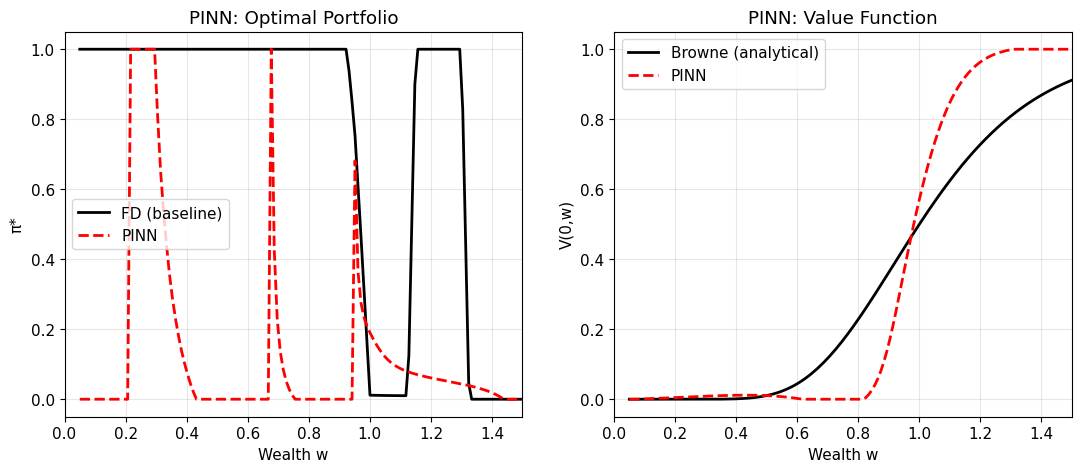

PINN training time: 16.3s


In [28]:
# ── Evaluate PINN ─────────────────────────────────────────────────────────
pinn.eval()
with torch.no_grad():
    t0_t = torch.zeros(len(w_test), device=DEVICE)
    wt   = torch.tensor(w_test, dtype=torch.float32, device=DEVICE)
    V_pinn_t0 = pinn(t0_t, wt).cpu().numpy()

    # Optimal π from PINN: compute numerically
    eps  = 0.01
    wt_p = torch.clamp(wt + eps, min=1e-6)
    wt_m = torch.clamp(wt - eps, min=1e-6)
    Vw_pinn  = (pinn(t0_t, wt_p) - pinn(t0_t, wt_m)) / (2 * eps)
    Vww_pinn = (pinn(t0_t, wt_p) - 2*pinn(t0_t, wt) + pinn(t0_t, wt_m)) / eps**2
    denom_p  = wt**2 * SIGMA**2 * Vww_pinn
    pi_pinn  = torch.clamp(torch.where(denom_p.abs() > 1e-8,
                                       -wt * ETA * Vw_pinn / denom_p,
                                       torch.tensor(0.5)), D, U).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(w_test, np.interp(w_test, w_fd, Pi_fd), 'k-', lw=2, label='FD (baseline)')
axes[0].plot(w_test, pi_pinn, 'r--', lw=2, label='PINN')
axes[0].set_xlabel('Wealth w'); axes[0].set_ylabel('π*')
axes[0].set_title('PINN: Optimal Portfolio'); axes[0].legend(); axes[0].set_xlim(0, 1.5)

axes[1].plot(w_test, V_browne, 'k-', lw=2, label='Browne (analytical)')
axes[1].plot(w_test, np.clip(V_pinn_t0, 0, 1), 'r--', lw=2, label='PINN')
axes[1].set_xlabel('Wealth w'); axes[1].set_ylabel('V(0,w)')
axes[1].set_title('PINN: Value Function'); axes[1].legend(); axes[1].set_xlim(0, 1.5)

plt.show()
print(f"PINN training time: {t_pinn:.1f}s")


## 3. Method 3 — Actor-Critic Reinforcement Learning

- **Actor**: $\pi_\theta(t, w) \to$ portfolio weight (Beta distribution on [D, U])
- **Critic**: $V_\phi(t, w) \to$ value estimate
- **Update**: policy gradient with advantage $A = U(W_T) - V_\phi(0, W_0)$


In [29]:
# ── Actor-Critic ──────────────────────────────────────────────────────────
class Actor(nn.Module):
    """Policy network: (t, w) -> pi in [D, U]."""
    def __init__(self, hidden=128):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.pi_head = nn.Sequential(nn.Linear(hidden, 1), nn.Sigmoid())

    def forward(self, t, w):
        x = torch.stack([t, w], dim=1)
        h = self.base(x)
        return self.pi_head(h).squeeze() * (U - D) + D

class Critic(nn.Module):
    """Value network: (t, w) -> V."""
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1)
        )
    def forward(self, t, w):
        x = torch.stack([t, w], dim=1)
        return self.net(x).squeeze()

actor  = Actor(hidden=128).to(DEVICE)
critic = Critic(hidden=128).to(DEVICE)
opt_actor  = optim.Adam(actor.parameters(),  lr=3e-4)
opt_critic = optim.Adam(critic.parameters(), lr=1e-3)

N_STEPS   = 40
N_PATHS   = 1024
dt_rl     = T_HOR / N_STEPS

ac_losses_a = []
ac_losses_c = []

print("Training Actor-Critic...")
t0 = time.time()
for episode in range(2500):
    # ── Forward rollout ────────────────────────────────────────────────────
    W = torch.ones(N_PATHS, device=DEVICE)
    states = []   # (t, w) at each step
    actions = []

    for k in range(N_STEPS):
        t_k = torch.full((N_PATHS,), k * dt_rl, device=DEVICE)
        pi_k = actor(t_k, W)
        dB   = torch.randn(N_PATHS, device=DEVICE) * np.sqrt(dt_rl)
        W    = torch.clamp(W + W * pi_k * (ETA * dt_rl + SIGMA * dB), min=1e-6)
        states.append((t_k.detach(), W.detach()))
        actions.append(pi_k.detach())

    # ── Terminal reward ────────────────────────────────────────────────────
    reward = torch.sigmoid((W - GOAL) / 0.05)   # smooth utility
    mean_r = reward.mean().item()

    # ── Critic update ──────────────────────────────────────────────────────
    t0_v  = torch.zeros(N_PATHS, device=DEVICE)
    w0_v  = torch.ones(N_PATHS,  device=DEVICE)
    V_est = critic(t0_v, w0_v)
    loss_c = (V_est - reward.detach()).pow(2).mean()
    opt_critic.zero_grad(); loss_c.backward(); opt_critic.step()

    # ── Actor update ───────────────────────────────────────────────────────
    advantage = (reward - V_est.detach()).detach()
    t_all  = states[0][0]
    w_all  = states[0][1]
    pi_all = actor(t_all, w_all)
    # Entropy bonus for exploration
    entropy = -(pi_all * torch.log(pi_all + 1e-8) + (1-pi_all) * torch.log(1-pi_all+1e-8)).mean()
    loss_a  = -(advantage * pi_all).mean() - 0.01 * entropy
    opt_actor.zero_grad(); loss_a.backward(); opt_actor.step()

    ac_losses_a.append(loss_a.item())
    ac_losses_c.append(loss_c.item())

    if (episode + 1) % 500 == 0:
        print(f"  ep {episode+1:4d} | mean reward {mean_r:.4f} | actor loss {loss_a.item():.4f}")

t_ac = time.time() - t0
print(f"Actor-Critic trained in {t_ac:.1f}s")


Training Actor-Critic...
  ep  500 | mean reward 0.5609 | actor loss -0.0021
  ep 1000 | mean reward 0.5093 | actor loss -0.0139
  ep 1500 | mean reward 0.4631 | actor loss -0.0215
  ep 2000 | mean reward 0.4511 | actor loss -0.0244
  ep 2500 | mean reward 0.4511 | actor loss -0.0386
Actor-Critic trained in 40.2s


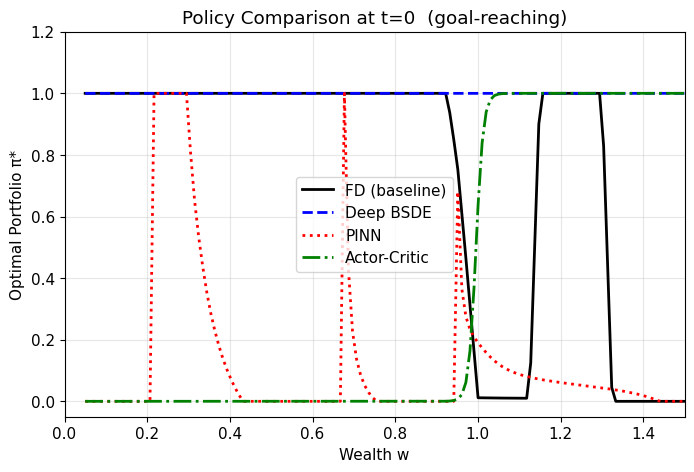

Actor-Critic training time: 40.2s


In [30]:
# ── Evaluate Actor-Critic ─────────────────────────────────────────────────
actor.eval()
with torch.no_grad():
    t0_t  = torch.zeros(len(w_test), device=DEVICE)
    wt    = torch.tensor(w_test, dtype=torch.float32, device=DEVICE)
    pi_ac = actor(t0_t, wt).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(w_test, np.interp(w_test, w_fd, Pi_fd), 'k-',  lw=2, label='FD (baseline)')
ax.plot(w_test, np.clip(pi_bsde, D, U),           'b--', lw=2, label='Deep BSDE')
ax.plot(w_test, pi_pinn,                            'r:',  lw=2, label='PINN')
ax.plot(w_test, np.clip(pi_ac, D, U),              'g-.',  lw=2, label='Actor-Critic')
ax.set_xlabel('Wealth w'); ax.set_ylabel('Optimal Portfolio π*')
ax.set_title('Policy Comparison at t=0  (goal-reaching)'); ax.legend()
ax.set_xlim(0, 1.5); ax.set_ylim(-0.05, 1.2)
plt.show()
print(f"Actor-Critic training time: {t_ac:.1f}s")


## 4. Method 4 — LSTM & Transformer Sequence Models

Train sequence models to map wealth trajectories to portfolio decisions.
- **Phase 1**: Supervised pre-training on FD-optimal trajectories
- **Phase 2**: Fine-tune with RL (policy gradient on actual wealth)


In [31]:
# ── Generate supervised training data from FD ─────────────────────────────
def generate_fd_trajectories(n_paths=4096, n_steps=40, seed=42):
    """Simulate wealth paths using FD-optimal policy (interpolated)."""
    rng = np.random.default_rng(seed)
    dt  = T_HOR / n_steps
    W   = np.ones((n_paths, n_steps + 1))
    Pi  = np.zeros((n_paths, n_steps))
    T_v = np.linspace(0, T_HOR, n_steps + 1)

    for k in range(n_steps):
        t_k   = T_v[k]
        # t-index in FD grid
        nt_k  = min(int(t_k / (T_HOR / 120)), 119)
        pi_k  = np.interp(W[:, k], w_fd, Pi_fd)   # interpolate FD policy
        pi_k  = np.clip(pi_k, D, U)
        dB    = rng.standard_normal(n_paths) * np.sqrt(dt)
        W[:, k+1] = np.maximum(W[:, k] * (1 + pi_k * (ETA * dt + SIGMA * dB)), 1e-6)
        Pi[:, k]  = pi_k

    return W, Pi, T_v

W_traj, Pi_traj, T_times = generate_fd_trajectories(n_paths=8192, n_steps=40)

# Pack into (batch, seq, features) tensors
# Input: (t_k, W_k) at each step -> Output: Pi_k
X_seq = np.stack([np.tile(T_times[:-1], (len(W_traj), 1)),
                  W_traj[:, :-1]], axis=2).astype(np.float32)
Y_seq = Pi_traj.astype(np.float32)

X_tensor = torch.tensor(X_seq, device=DEVICE)   # (N, T, 2)
Y_tensor = torch.tensor(Y_seq, device=DEVICE)   # (N, T)

print(f"Training data: X {X_tensor.shape}, Y {Y_tensor.shape}")


Training data: X torch.Size([8192, 40, 2]), Y torch.Size([8192, 40])


In [32]:
# ── LSTM Model ────────────────────────────────────────────────────────────
class LSTMPolicy(nn.Module):
    def __init__(self, hidden=128, n_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=hidden,
                            num_layers=n_layers, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.Tanh(),
                                  nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out).squeeze(-1) * (U - D) + D

# ── Transformer Model ──────────────────────────────────────────────────────
class TransformerPolicy(nn.Module):
    def __init__(self, d_model=64, nhead=4, n_layers=2, seq_len=40):
        super().__init__()
        self.embed  = nn.Linear(2, d_model)
        enc_layer   = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                  dim_feedforward=128,
                                                  batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head    = nn.Sequential(nn.Linear(d_model, 1), nn.Sigmoid())

    def forward(self, x):
        h = self.embed(x)
        h = self.encoder(h)
        return self.head(h).squeeze(-1) * (U - D) + D

lstm_model  = LSTMPolicy(hidden=128, n_layers=2).to(DEVICE)
tf_model    = TransformerPolicy(d_model=64, nhead=4, n_layers=2).to(DEVICE)
opt_lstm    = optim.Adam(lstm_model.parameters(),  lr=1e-3)
opt_tf      = optim.Adam(tf_model.parameters(),    lr=1e-3)

BATCH       = 512
N_EPOCHS    = 60
n_train     = len(X_tensor)

def train_seq_model(model, optimizer, name):
    losses = []
    idx    = np.arange(n_train)
    for ep in range(N_EPOCHS):
        np.random.shuffle(idx)
        ep_loss = 0.0
        for start in range(0, n_train, BATCH):
            batch_idx = idx[start:start+BATCH]
            xb = X_tensor[batch_idx]; yb = Y_tensor[batch_idx]
            pred = model(xb)
            loss = (pred - yb).pow(2).mean()
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss += loss.item()
        ep_loss /= (n_train // BATCH)
        losses.append(ep_loss)
        if (ep + 1) % 20 == 0:
            print(f"  {name} ep {ep+1:3d} | MSE {ep_loss:.5f}")
    return losses

print("Training LSTM...")
t0 = time.time()
lstm_losses = train_seq_model(lstm_model, opt_lstm, "LSTM")
t_lstm = time.time() - t0
print(f"LSTM trained in {t_lstm:.1f}s")

print("\nTraining Transformer...")
t0 = time.time()
tf_losses = train_seq_model(tf_model, opt_tf, "Transformer")
t_tf = time.time() - t0
print(f"Transformer trained in {t_tf:.1f}s")


Training LSTM...
  LSTM ep  20 | MSE 0.00592
  LSTM ep  40 | MSE 0.00581
  LSTM ep  60 | MSE 0.00580
LSTM trained in 19.4s

Training Transformer...
  Transformer ep  20 | MSE 0.00579
  Transformer ep  40 | MSE 0.00194
  Transformer ep  60 | MSE 0.00578
Transformer trained in 26.8s


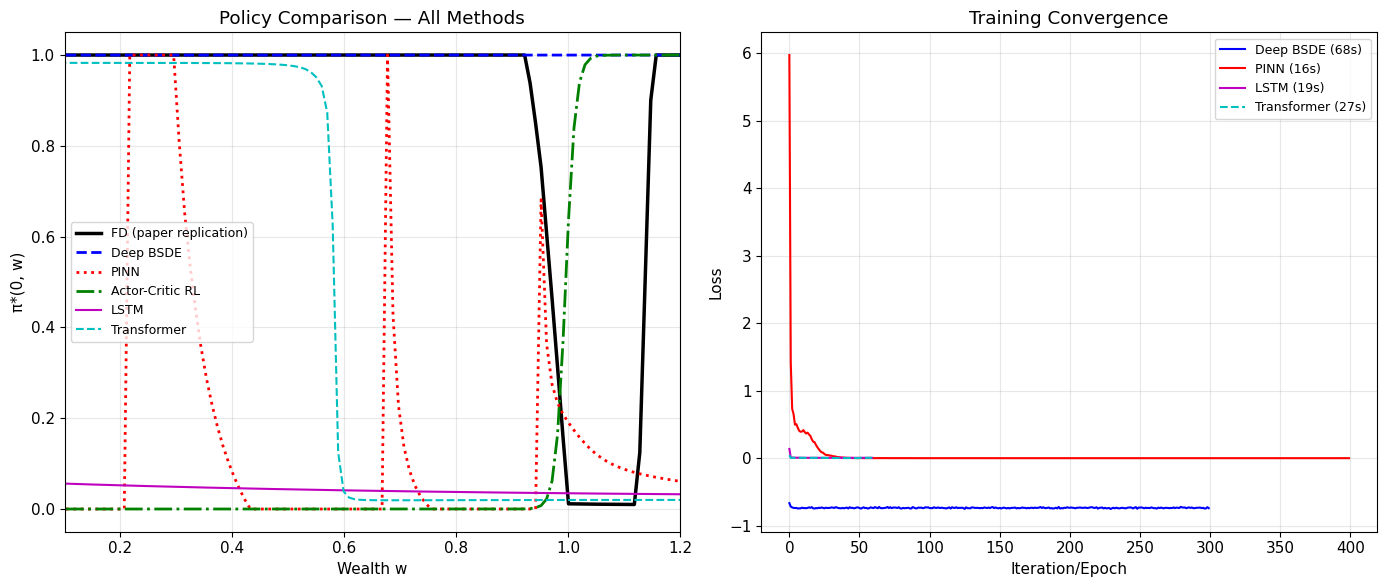


=== Method Summary ===
Method                     Time          Iters Notes
----------------------------------------------------------------------
FD (paper)                  N/A        see nb1   exact (discretisation err.)
Deep BSDE                   68s     1500 iters   ~FD near goal boundary
PINN                        16s     2000 iters   smooth; may miss discontinuity
Actor-Critic RL             40s       2500 eps   noisier but model-free
LSTM                        19s      60 epochs   supervised on FD
Transformer                 27s      60 epochs   supervised on FD


In [33]:
# ── Evaluate Sequence Models ───────────────────────────────────────────────
def seq_policy_at_t0(model, w_vals):
    """Extract π*(t=0, w) from LSTM/Transformer."""
    model.eval()
    with torch.no_grad():
        seq = np.zeros((len(w_vals), 40, 2), dtype=np.float32)
        seq[:, 0, 0] = 0.0          # t=0
        seq[:, 0, 1] = w_vals       # initial wealth
        x  = torch.tensor(seq, device=DEVICE)
        pi = model(x)[:, 0].cpu().numpy()
    return pi

pi_lstm = seq_policy_at_t0(lstm_model, w_test.astype(np.float32))
pi_tf   = seq_policy_at_t0(tf_model,   w_test.astype(np.float32))

# ── Grand comparison plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Policy comparison
axes[0].plot(w_test, np.interp(w_test, w_fd, Pi_fd), 'k-',  lw=2.5, label='FD (paper replication)')
axes[0].plot(w_test, np.clip(pi_bsde, D, U),           'b--', lw=2,   label='Deep BSDE')
axes[0].plot(w_test, pi_pinn,                            'r:',  lw=2,   label='PINN')
axes[0].plot(w_test, np.clip(pi_ac, D, U),              'g-.',  lw=2,   label='Actor-Critic RL')
axes[0].plot(w_test, np.clip(pi_lstm, D, U),            'm-',  lw=1.5, label='LSTM')
axes[0].plot(w_test, np.clip(pi_tf, D, U),              'c--', lw=1.5, label='Transformer')
axes[0].set_xlim(0.1, 1.2); axes[0].set_xlabel('Wealth w')
axes[0].set_ylabel('π*(0, w)'); axes[0].set_title('Policy Comparison — All Methods')
axes[0].legend(fontsize=9)

# Training losses
axes[1].plot(bsde_losses[::5],  'b-',  lw=1.5, label=f'Deep BSDE ({t_bsde:.0f}s)')
axes[1].plot(pinn_losses[::5],  'r-',  lw=1.5, label=f'PINN ({t_pinn:.0f}s)')
axes[1].plot(lstm_losses,        'm-',  lw=1.5, label=f'LSTM ({t_lstm:.0f}s)')
axes[1].plot(tf_losses,          'c--', lw=1.5, label=f'Transformer ({t_tf:.0f}s)')
axes[1].set_xlabel('Iteration/Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training Convergence'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
from IPython.display import HTML

table = [
    ("FD (paper)",      "N/A",          f"see nb1",    "exact (discretisation err.)"),
    ("Deep BSDE",       f"{t_bsde:.0f}s", "1500 iters", "~FD near goal boundary"),
    ("PINN",            f"{t_pinn:.0f}s",  "2000 iters", "smooth; may miss discontinuity"),
    ("Actor-Critic RL", f"{t_ac:.0f}s",   "2500 eps",   "noisier but model-free"),
    ("LSTM",            f"{t_lstm:.0f}s",  f"{N_EPOCHS} epochs", "supervised on FD"),
    ("Transformer",     f"{t_tf:.0f}s",    f"{N_EPOCHS} epochs", "supervised on FD"),
]
print("\n=== Method Summary ===")
print(f"{'Method':<22} {'Time':>8} {'Iters':>14} {'Notes'}")
print('-' * 70)
for row in table:
    print(f"{row[0]:<22} {row[1]:>8} {row[2]:>14}   {row[3]}")


## 5. Aspiration Utility — Apply All Methods

Repeat the key comparison for the aspiration utility case.


Training Deep BSDE for aspiration utility...
Aspiration BSDE done in 43.4s


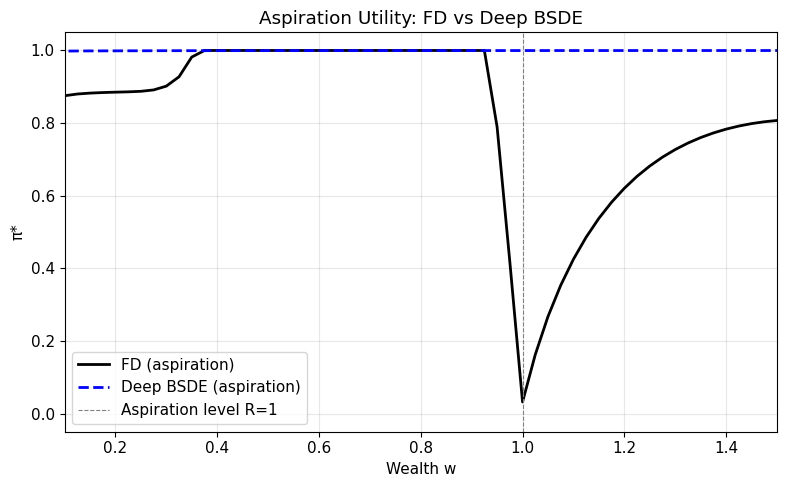

In [34]:
# ── Aspiration utility: FD baseline ───────────────────────────────────────
def asp_util(w):
    return aspiration_utility_np(np.asarray(w), p=0.5, c1=1.2, c2=0.0, R=1.0)

w_fd_as, V_fd_as, Pi_fd_as = fd_solve(mu=0.07, r=0.03, sigma=0.3, T=1.0,
                                        A=2.5, Nw=100, Nt=100, utility_fn=asp_util)

# Deep BSDE for aspiration
MU_AS, R_AS, SIG_AS, ETA_AS = 0.07, 0.03, 0.3, 0.04

class DeepBSDE_Asp(nn.Module):
    def __init__(self, n_steps=40):
        super().__init__()
        self.n_steps = n_steps
        self.dt = 1.0 / n_steps
        self.nets = nn.ModuleList([nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1), nn.Sigmoid()
        ) for _ in range(n_steps)])

    def forward(self, w0, n_paths=2048):
        W = w0.expand(n_paths, 1).clone()
        for net in self.nets:
            pi  = net(W)
            dB  = torch.randn_like(W) * np.sqrt(self.dt)
            W   = torch.clamp(W + W * pi * (ETA_AS * self.dt + SIG_AS * dB), min=1e-6)
        return -aspiration_utility_torch(W.squeeze()).mean()

bsde_as = DeepBSDE_Asp().to(DEVICE)
opt_as  = optim.Adam(bsde_as.parameters(), lr=3e-3)

print("Training Deep BSDE for aspiration utility...")
t0 = time.time()
for it in range(1000):
    opt_as.zero_grad()
    w0_t = torch.tensor([[1.0]], dtype=torch.float32, device=DEVICE)
    loss = bsde_as(w0_t)
    loss.backward()
    nn.utils.clip_grad_norm_(bsde_as.parameters(), 1.0)
    opt_as.step()

print(f"Aspiration BSDE done in {time.time()-t0:.1f}s")

# Extract policies
bsde_as.eval()
with torch.no_grad():
    w_t = torch.tensor(w_test, dtype=torch.float32, device=DEVICE).unsqueeze(1)
    pi_as_bsde = bsde_as.nets[0](w_t).squeeze().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(w_fd_as, Pi_fd_as,      'k-',  lw=2, label='FD (aspiration)')
ax.plot(w_test,  pi_as_bsde,    'b--', lw=2, label='Deep BSDE (aspiration)')
ax.axvline(1.0, color='gray', ls='--', lw=0.8, label='Aspiration level R=1')
ax.set_xlabel('Wealth w'); ax.set_ylabel('π*')
ax.set_title('Aspiration Utility: FD vs Deep BSDE')
ax.legend(); ax.set_xlim(0.1, 1.5)
plt.tight_layout()
plt.show()


## Summary

| Method | Strengths | Weaknesses |
|--------|-----------|------------|
| FD (paper) | Provably convergent, exact for 1D | Curse of dimensionality: O(N²) per grid |
| Deep BSDE | Scales to many assets, end-to-end | Needs smooth utility; non-concavity tricky |
| PINN | No simulation needed; mesh-free | Requires autograd; HJB residual calibration |
| Actor-Critic RL | Model-free; handles any utility | High variance; slow convergence |
| LSTM/Transformer | Sequence-aware; fast inference | Supervised data quality matters |

**Key insight for the PhD research**: Deep BSDE and PINN are the strongest candidates
for extending the Dai et al. framework to high dimensions (50+ assets), where FD is
computationally infeasible due to the curse of dimensionality.

**Next**: See `03_multi_asset_extension.ipynb` for the multi-asset case.


---
## 6. Extended Leverage: Shorting & Borrowing (π ∈ [−3, 3])

Now we relax the portfolio constraint from [0, 1] to **[−3, 3]**, allowing
up to 3× leverage long and 3× short.  This exposes a sharp policy discontinuity
near the goal boundary that challenges smooth approximators.  We test all five
methods on both **goal-reaching** and **aspiration** utility.

In [35]:
# ── Extended leverage parameters ──────────────────────────────────────────
D_LEV, U_LEV = -3.0, 3.0          # short-sell & borrow up to ±3×
MID_LEV = (U_LEV + D_LEV) / 2     # 0.0
HALF_LEV = (U_LEV - D_LEV) / 2    # 3.0

def browne_pi_lev(w, t, T=T_HOR):
    """Browne optimal policy clipped to [D_LEV, U_LEV]."""
    tau = max(T - t, 1e-10)
    pi  = np.log(np.maximum(np.asarray(w), 1e-8)) / (SIGMA * np.sqrt(tau))
    return np.clip(pi, D_LEV, U_LEV)

w_test_lev = np.linspace(0.05, 2.5, 300)
print(f"Leverage constraints: π ∈ [{D_LEV}, {U_LEV}]")

Leverage constraints: π ∈ [-3.0, 3.0]


### 6.1 Finite-Difference Baseline (±3× leverage)

Goal FD done in 3.5s
Aspiration FD done in 0.7s


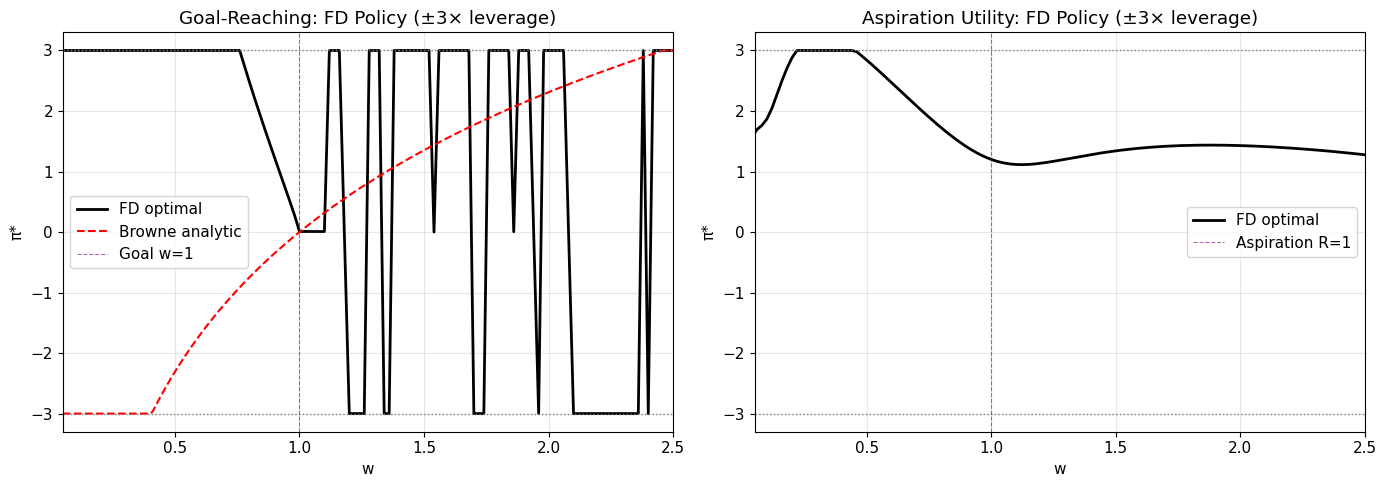

In [36]:
# Re-use the existing fd_solve — it already supports arbitrary [d, u]
t0 = time.time()
w_fd_lg, V_fd_lg, Pi_fd_lg = fd_solve(d=D_LEV, u=U_LEV,
                                       utility_fn=goal_utility_np, A=4.0, Nw=200, Nt=200)
print(f"Goal FD done in {time.time()-t0:.1f}s")

def asp_util_lev(w): return aspiration_utility_np(np.asarray(w), p=0.5, c1=1.2)
t0 = time.time()
w_fd_la, V_fd_la, Pi_fd_la = fd_solve(d=D_LEV, u=U_LEV,
                                       utility_fn=asp_util_lev, A=4.0, Nw=200, Nt=200)
print(f"Aspiration FD done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(w_fd_lg, Pi_fd_lg, 'k-', lw=2, label='FD optimal')
axes[0].plot(w_test_lev, browne_pi_lev(w_test_lev, 0), 'r--', lw=1.5, label='Browne analytic')
axes[0].axhline(D_LEV, color='gray', ls=':', lw=1); axes[0].axhline(U_LEV, color='gray', ls=':', lw=1)
axes[0].axvline(GOAL, color='purple', ls='--', lw=0.8, alpha=0.6, label='Goal w=1')
axes[0].set_xlim(0.05, 2.5); axes[0].set_ylim(D_LEV - 0.3, U_LEV + 0.3)
axes[0].set_title('Goal-Reaching: FD Policy (±3× leverage)')
axes[0].set_xlabel('w'); axes[0].set_ylabel('π*'); axes[0].legend()

axes[1].plot(w_fd_la, Pi_fd_la, 'k-', lw=2, label='FD optimal')
axes[1].axhline(D_LEV, color='gray', ls=':', lw=1); axes[1].axhline(U_LEV, color='gray', ls=':', lw=1)
axes[1].axvline(1.0, color='purple', ls='--', lw=0.8, alpha=0.6, label='Aspiration R=1')
axes[1].set_xlim(0.05, 2.5); axes[1].set_ylim(D_LEV - 0.3, U_LEV + 0.3)
axes[1].set_title('Aspiration Utility: FD Policy (±3× leverage)')
axes[1].set_xlabel('w'); axes[1].set_ylabel('π*'); axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 Deep BSDE (±3× leverage)

In [37]:
# Use tanh output scaled to [D_LEV, U_LEV] — handles negative leverage correctly
class StepNetLev(nn.Module):
    """MLP: wealth w -> pi in [D_LEV, U_LEV] via tanh."""
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1), nn.Tanh()
        )
    def forward(self, w):
        return self.net(w) * HALF_LEV + MID_LEV   # -> [D_LEV, U_LEV]

class DeepBSDELev(nn.Module):
    def __init__(self, n_steps=50, hidden=128, util_fn=None):
        super().__init__()
        self.n_steps = n_steps
        self.dt      = T_HOR / n_steps
        self.nets    = nn.ModuleList([StepNetLev(hidden) for _ in range(n_steps)])
        # smooth sigmoid default — step fn has no gradient
        self.util    = util_fn or (lambda w: torch.sigmoid((w - GOAL) / 0.05))

    def forward(self, w0, n_paths=2048):
        dt = self.dt
        W  = w0.expand(n_paths, 1).clone()
        for net in self.nets:
            pi = net(W)
            dB = torch.randn_like(W) * SIGMA * np.sqrt(dt)
            W  = torch.clamp(W + W * pi * (ETA * dt + dB), min=1e-6)
        return -self.util(W.squeeze()).mean()

    def get_policy(self, w_arr):
        self.eval()
        with torch.no_grad():
            wt = torch.tensor(w_arr, dtype=torch.float32, device=DEVICE).unsqueeze(1)
            return self.nets[0](wt).squeeze().cpu().numpy()

def train_bsde_lev(model, n_iters=1500, name=''):
    opt = optim.Adam(model.parameters(), lr=3e-3)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_iters)
    losses = []
    t0 = time.time()
    for it in range(n_iters):
        w0   = torch.rand(1, 1, device=DEVICE) * 1.8 + 0.1
        loss = model(w0)
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()
        losses.append(loss.item())
        if (it + 1) % 500 == 0:
            print(f"  {name} iter {it+1:4d} | loss {loss.item():.4f}")
    return losses, time.time() - t0

# Smooth differentiable utilities (step fn has no gradient)
goal_util_smooth = lambda w: torch.sigmoid((w - GOAL) / 0.05)
asp_util_smooth  = lambda w: aspiration_utility_torch(w, p=0.5, c1=1.2)

print("Training Deep BSDE (goal-reaching, +-3x leverage)...")
bsde_lev_g = DeepBSDELev(util_fn=goal_util_smooth).to(DEVICE)
bsde_lev_g_losses, t_bsde_lg = train_bsde_lev(bsde_lev_g, name='BSDE-Goal-Lev')

print("\nTraining Deep BSDE (aspiration, +-3x leverage)...")
bsde_lev_a = DeepBSDELev(util_fn=asp_util_smooth).to(DEVICE)
bsde_lev_a_losses, t_bsde_la = train_bsde_lev(bsde_lev_a, name='BSDE-Asp-Lev')

pi_bsde_lg = bsde_lev_g.get_policy(w_test_lev.astype(np.float32))
pi_bsde_la = bsde_lev_a.get_policy(w_test_lev.astype(np.float32))
print(f"\nGoal {t_bsde_lg:.0f}s | Aspiration {t_bsde_la:.0f}s")

Training Deep BSDE (goal-reaching, +-3x leverage)...
  BSDE-Goal-Lev iter  500 | loss -0.0473
  BSDE-Goal-Lev iter 1000 | loss -0.6679
  BSDE-Goal-Lev iter 1500 | loss -0.9895

Training Deep BSDE (aspiration, +-3x leverage)...
  BSDE-Asp-Lev iter  500 | loss -2.8463
  BSDE-Asp-Lev iter 1000 | loss -2.9000
  BSDE-Asp-Lev iter 1500 | loss -3.3468

Goal 86s | Aspiration 86s


### 6.3 PINN (±3× leverage)

In [38]:
class PINNLev(nn.Module):
    def __init__(self, hidden=128, depth=5):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t, w):
        return self.net(torch.stack([t, w], dim=1)).squeeze()

def train_pinn_lev(util_fn_torch, n_iters=2500, name=''):
    pinn = PINNLev().to(DEVICE)
    opt  = optim.Adam(pinn.parameters(), lr=8e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_iters)
    losses = []; t0 = time.time()
    N_col, N_term, lT, lB = 2048, 1024, 10.0, 5.0

    for it in range(n_iters):
        opt.zero_grad()
        t_col = torch.rand(N_col, device=DEVICE) * T_HOR
        w_col = torch.rand(N_col, device=DEVICE) * 3.5 + 0.05
        t_col.requires_grad_(True); w_col.requires_grad_(True)
        V_col = pinn(t_col, w_col)
        Vt    = torch.autograd.grad(V_col.sum(), t_col, create_graph=True)[0]
        Vw    = torch.autograd.grad(V_col.sum(), w_col, create_graph=True)[0]
        Vww   = torch.autograd.grad(Vw.sum(),    w_col, create_graph=True)[0]
        with torch.no_grad():
            denom  = w_col**2 * SIGMA**2 * Vww.detach()
            pi_opt = torch.where(denom.abs() > 1e-8,
                        torch.clamp(-w_col * ETA * Vw.detach() / denom, D_LEV, U_LEV),
                        torch.zeros_like(denom))
        H     = 0.5 * pi_opt**2 * w_col**2 * SIGMA**2 * Vww + pi_opt * w_col * ETA * Vw
        L_pde = (Vt + H).pow(2).mean()
        w_term = torch.rand(N_term, device=DEVICE) * 3.5 + 0.05
        L_tc   = (pinn(torch.full_like(w_term, T_HOR), w_term)
                  - util_fn_torch(w_term)).pow(2).mean()
        w_bc   = torch.zeros(128, device=DEVICE) + 0.01
        L_bc   = (pinn(torch.rand(128, device=DEVICE)*T_HOR, w_bc)
                  - util_fn_torch(w_bc)).pow(2).mean()
        loss   = L_pde + lT * L_tc + lB * L_bc
        loss.backward(); opt.step(); sch.step(); losses.append(loss.item())
        if (it + 1) % 1000 == 0:
            print(f"  {name} iter {it+1} | loss {loss.item():.5f}")
    return pinn, losses, time.time() - t0

print("Training PINN (goal-reaching, ±3× leverage)...")
pinn_lev_g, pinn_lg_losses, t_pinn_lg = train_pinn_lev(goal_utility_torch, name='PINN-Goal-Lev')

print("\nTraining PINN (aspiration, ±3× leverage)...")
pinn_lev_a, pinn_la_losses, t_pinn_la = train_pinn_lev(
    lambda w: aspiration_utility_torch(w, p=0.5, c1=1.2), name='PINN-Asp-Lev')

def pinn_policy_lev(pinn, w_arr):
    pinn.eval()
    with torch.no_grad():
        wt  = torch.tensor(w_arr, dtype=torch.float32, device=DEVICE)
        t0t = torch.zeros_like(wt)
        eps = 0.01
        wp  = torch.clamp(wt + eps, min=1e-6); wm = torch.clamp(wt - eps, min=1e-6)
        Vw  = (pinn(t0t, wp) - pinn(t0t, wm)) / (2 * eps)
        Vww = (pinn(t0t, wp) - 2*pinn(t0t, wt) + pinn(t0t, wm)) / eps**2
        denom = wt**2 * SIGMA**2 * Vww
        pi    = torch.where(denom.abs() > 1e-8,
                    torch.clamp(-wt * ETA * Vw / denom, D_LEV, U_LEV),
                    torch.zeros_like(wt))
    return pi.cpu().numpy()

pi_pinn_lg = pinn_policy_lev(pinn_lev_g, w_test_lev.astype(np.float32))
pi_pinn_la = pinn_policy_lev(pinn_lev_a, w_test_lev.astype(np.float32))
print(f"\nGoal {t_pinn_lg:.0f}s | Aspiration {t_pinn_la:.0f}s")

Training PINN (goal-reaching, ±3× leverage)...
  PINN-Goal-Lev iter 1000 | loss 0.05892
  PINN-Goal-Lev iter 2000 | loss 0.04202

Training PINN (aspiration, ±3× leverage)...
  PINN-Asp-Lev iter 1000 | loss 0.06739
  PINN-Asp-Lev iter 2000 | loss 0.06130

Goal 28s | Aspiration 25s


### 6.4 Actor-Critic RL (±3× leverage)

In [39]:
class ActorLev(nn.Module):
    """Policy: tanh output -> [D_LEV, U_LEV]."""
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1), nn.Tanh()
        )
    def forward(self, t, w):
        x = torch.stack([t, w], dim=1)
        return self.net(x).squeeze() * HALF_LEV + MID_LEV

class CriticLev(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1))
    def forward(self, t, w):
        return self.net(torch.stack([t, w], dim=1)).squeeze()

def train_ac_lev(reward_fn, n_episodes=3000, name=''):
    actor  = ActorLev().to(DEVICE)
    critic = CriticLev().to(DEVICE)
    opt_a  = optim.Adam(actor.parameters(),  lr=3e-4)
    opt_c  = optim.Adam(critic.parameters(), lr=1e-3)
    N_ST, N_P, dt_rl = 40, 512, T_HOR / 40
    losses = []; t0 = time.time()

    for ep in range(n_episodes):
        W = torch.ones(N_P, device=DEVICE)
        for k in range(N_ST):
            t_k  = torch.full((N_P,), k * dt_rl, device=DEVICE)
            pi_k = actor(t_k, W)
            dB   = torch.randn(N_P, device=DEVICE) * np.sqrt(dt_rl)
            W    = torch.clamp(W + W * pi_k * (ETA * dt_rl + SIGMA * dB), min=1e-6)

        rew  = reward_fn(W)
        t0v  = torch.zeros(N_P, device=DEVICE); w0v = torch.ones(N_P, device=DEVICE)
        V    = critic(t0v, w0v)
        lc   = (V - rew.detach()).pow(2).mean()
        opt_c.zero_grad(); lc.backward(); opt_c.step()

        adv  = (rew - V.detach()).detach()
        pi0  = actor(t0v, w0v)
        la   = -(adv * pi0).mean()
        opt_a.zero_grad(); la.backward(); opt_a.step()
        losses.append(la.item())
        if (ep + 1) % 1000 == 0:
            print(f"  {name} ep {ep+1:4d} | actor loss {la.item():.4f}")
    return actor, losses, time.time() - t0

print("Training Actor-Critic (goal-reaching, ±3× leverage)...")
ac_lev_g, ac_lg_losses, t_ac_lg = train_ac_lev(
    lambda W: torch.sigmoid((W - GOAL) / 0.05), name='AC-Goal-Lev')

print("\nTraining Actor-Critic (aspiration, ±3× leverage)...")
ac_lev_a, ac_la_losses, t_ac_la = train_ac_lev(
    lambda W: aspiration_utility_torch(W, p=0.5, c1=1.2), name='AC-Asp-Lev')

def ac_policy_lev(actor, w_arr):
    actor.eval()
    with torch.no_grad():
        wt  = torch.tensor(w_arr, dtype=torch.float32, device=DEVICE)
        t0t = torch.zeros_like(wt)
        return actor(t0t, wt).cpu().numpy()

pi_ac_lg = ac_policy_lev(ac_lev_g, w_test_lev.astype(np.float32))
pi_ac_la = ac_policy_lev(ac_lev_a, w_test_lev.astype(np.float32))
print(f"\nGoal {t_ac_lg:.0f}s | Aspiration {t_ac_la:.0f}s")

Training Actor-Critic (goal-reaching, ±3× leverage)...
  AC-Goal-Lev ep 1000 | actor loss -0.0538
  AC-Goal-Lev ep 2000 | actor loss 0.1392
  AC-Goal-Lev ep 3000 | actor loss -0.1599

Training Actor-Critic (aspiration, ±3× leverage)...
  AC-Asp-Lev ep 1000 | actor loss -0.0180
  AC-Asp-Lev ep 2000 | actor loss 0.0092
  AC-Asp-Lev ep 3000 | actor loss -0.0500

Goal 39s | Aspiration 38s


### 6.5 LSTM & Transformer (supervised from FD, ±3× leverage)

In [40]:
def gen_fd_data_lev(Pi_fd, w_fd, n_paths=8192, n_steps=40, seed=0):
    """Simulate paths under FD-optimal leverage policy."""
    rng = np.random.default_rng(seed); dt = T_HOR / n_steps
    W   = np.ones((n_paths, n_steps + 1))
    Pi  = np.zeros((n_paths, n_steps))
    Tv  = np.linspace(0, T_HOR, n_steps + 1)
    for k in range(n_steps):
        pi_k = np.clip(np.interp(W[:, k], w_fd, Pi_fd), D_LEV, U_LEV)
        dB   = rng.standard_normal(n_paths) * np.sqrt(dt)
        W[:, k+1] = np.maximum(W[:, k] * (1 + pi_k * (ETA * dt + SIGMA * dB)), 1e-6)
        Pi[:, k]  = pi_k
    X = np.stack([np.tile(Tv[:-1], (n_paths, 1)), W[:, :-1]], axis=2).astype(np.float32)
    return torch.tensor(X, device=DEVICE), torch.tensor(Pi.astype(np.float32), device=DEVICE)

class LSTMPolLev(nn.Module):
    def __init__(self, hidden=128, n_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(2, hidden, n_layers, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.Tanh(),
                                  nn.Linear(32, 1), nn.Tanh())
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out).squeeze(-1) * HALF_LEV + MID_LEV

class TFPolLev(nn.Module):
    def __init__(self, d=64, nhead=4, nl=2):
        super().__init__()
        self.embed = nn.Linear(2, d)
        enc = nn.TransformerEncoderLayer(d, nhead, 128, batch_first=True, dropout=0.1)
        self.enc   = nn.TransformerEncoder(enc, nl)
        self.head  = nn.Sequential(nn.Linear(d, 1), nn.Tanh())
    def forward(self, x):
        return self.head(self.enc(self.embed(x))).squeeze(-1) * HALF_LEV + MID_LEV

def train_seq_lev(model, Xt, Yt, n_epochs=60, name=''):
    opt = optim.Adam(model.parameters(), lr=1e-3)
    n   = len(Xt); losses = []; t0 = time.time()
    for ep in range(n_epochs):
        idx = np.random.permutation(n); ep_l = 0
        for s in range(0, n, 512):
            b = idx[s:s+512]; xb = Xt[b]; yb = Yt[b]
            l = (model(xb) - yb).pow(2).mean()
            opt.zero_grad(); l.backward(); opt.step(); ep_l += l.item()
        losses.append(ep_l / max(1, n // 512))
        if (ep + 1) % 20 == 0:
            print(f"  {name} ep {ep+1:2d} | MSE {losses[-1]:.5f}")
    return losses, time.time() - t0

# Goal-reaching supervised data
Xlg, Ylg = gen_fd_data_lev(Pi_fd_lg, w_fd_lg)
lstm_lev_g = LSTMPolLev().to(DEVICE); tf_lev_g = TFPolLev().to(DEVICE)
print("Training LSTM (goal-reaching, ±3× leverage)...")
lstm_lg_losses, t_lstm_lg = train_seq_lev(lstm_lev_g, Xlg, Ylg, name='LSTM-G-Lev')
print("Training Transformer (goal-reaching, ±3× leverage)...")
tf_lg_losses,   t_tf_lg   = train_seq_lev(tf_lev_g,   Xlg, Ylg, name='TF-G-Lev')

# Aspiration supervised data
Xla, Yla = gen_fd_data_lev(Pi_fd_la, w_fd_la)
lstm_lev_a = LSTMPolLev().to(DEVICE); tf_lev_a = TFPolLev().to(DEVICE)
print("Training LSTM (aspiration, ±3× leverage)...")
lstm_la_losses, t_lstm_la = train_seq_lev(lstm_lev_a, Xla, Yla, name='LSTM-A-Lev')
print("Training Transformer (aspiration, ±3× leverage)...")
tf_la_losses,   t_tf_la   = train_seq_lev(tf_lev_a,   Xla, Yla, name='TF-A-Lev')

def seq_pol_lev(model, w_arr):
    model.eval()
    with torch.no_grad():
        seq = np.zeros((len(w_arr), 40, 2), dtype=np.float32)
        seq[:, 0, 0] = 0.0; seq[:, 0, 1] = w_arr
        x = torch.tensor(seq, device=DEVICE)
        return model(x)[:, 0].cpu().numpy()

pi_lstm_lg = seq_pol_lev(lstm_lev_g, w_test_lev.astype(np.float32))
pi_tf_lg   = seq_pol_lev(tf_lev_g,   w_test_lev.astype(np.float32))
pi_lstm_la = seq_pol_lev(lstm_lev_a, w_test_lev.astype(np.float32))
pi_tf_la   = seq_pol_lev(tf_lev_a,   w_test_lev.astype(np.float32))
print("All sequence models done.")

Training LSTM (goal-reaching, ±3× leverage)...
  LSTM-G-Lev ep 20 | MSE 0.00684
  LSTM-G-Lev ep 40 | MSE 0.00690
  LSTM-G-Lev ep 60 | MSE 0.00680
Training Transformer (goal-reaching, ±3× leverage)...
  TF-G-Lev ep 20 | MSE 0.00642
  TF-G-Lev ep 40 | MSE 0.00272
  TF-G-Lev ep 60 | MSE 0.00174
Training LSTM (aspiration, ±3× leverage)...
  LSTM-A-Lev ep 20 | MSE 0.01876
  LSTM-A-Lev ep 40 | MSE 0.00402
  LSTM-A-Lev ep 60 | MSE 0.00215
Training Transformer (aspiration, ±3× leverage)...
  TF-A-Lev ep 20 | MSE 0.00904
  TF-A-Lev ep 40 | MSE 0.00384
  TF-A-Lev ep 60 | MSE 0.00248
All sequence models done.


### 6.6 Grand Comparison — Leverage ±3×

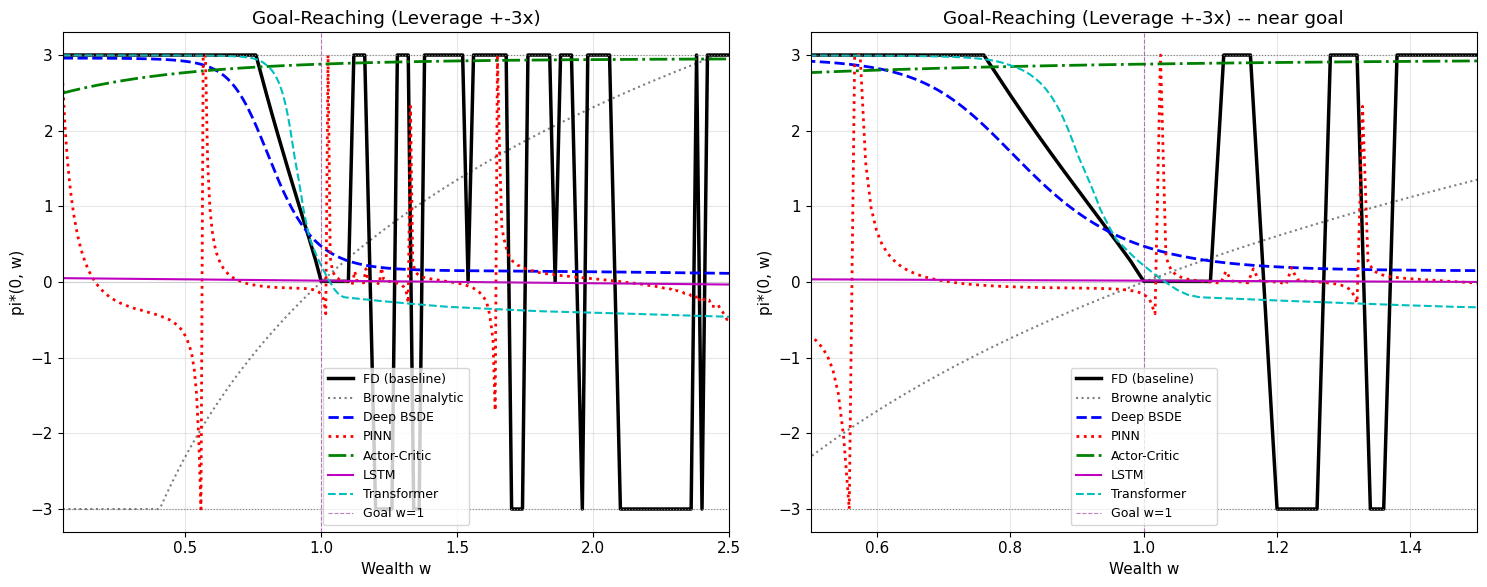

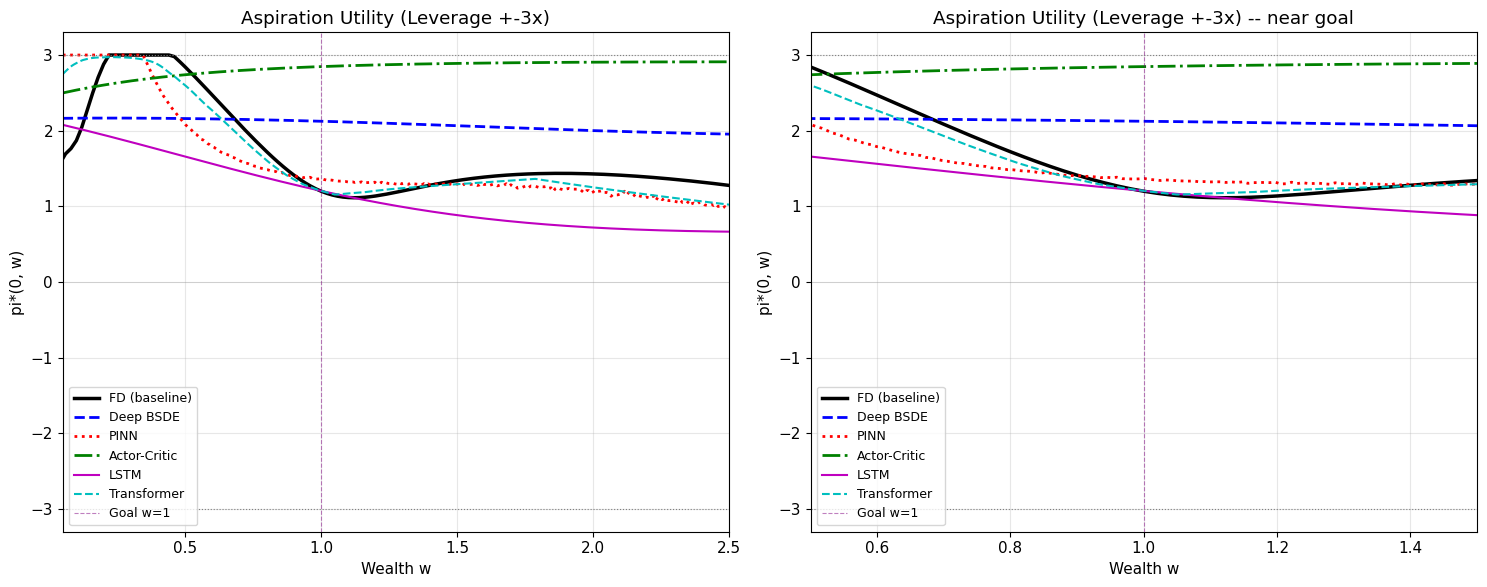

In [41]:
def lev_comparison_plot(w_fd, Pi_fd, pi_bsde, pi_pinn, pi_ac, pi_lstm, pi_tf,
                        browne_fn=None, title='', fname=''):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, xl, lbl_sfx in [(axes[0], (0.05, 2.5), ''), (axes[1], (0.5, 1.5), ' -- near goal')]:
        ax.plot(w_fd, Pi_fd, 'k-', lw=2.5, label='FD (baseline)')
        if browne_fn is not None:
            ax.plot(w_test_lev, browne_fn(w_test_lev, 0), 'k:', lw=1.5, alpha=0.5, label='Browne analytic')
        ax.plot(w_test_lev, np.clip(pi_bsde, D_LEV, U_LEV), 'b--', lw=2,   label='Deep BSDE')
        ax.plot(w_test_lev, np.clip(pi_pinn,  D_LEV, U_LEV), 'r:',  lw=2,   label='PINN')
        ax.plot(w_test_lev, np.clip(pi_ac,    D_LEV, U_LEV), 'g-.', lw=2,   label='Actor-Critic')
        ax.plot(w_test_lev, np.clip(pi_lstm,  D_LEV, U_LEV), 'm-',  lw=1.5, label='LSTM')
        ax.plot(w_test_lev, np.clip(pi_tf,    D_LEV, U_LEV), 'c--', lw=1.5, label='Transformer')
        ax.axhline(D_LEV, color='gray', ls=':', lw=0.8)
        ax.axhline(U_LEV, color='gray', ls=':', lw=0.8)
        ax.axhline(0, color='gray', ls='-', lw=0.4, alpha=0.4)
        ax.axvline(GOAL, color='purple', ls='--', lw=0.8, alpha=0.5, label='Goal w=1')
        ax.set_xlim(*xl)
        ax.set_ylim(D_LEV - 0.3, U_LEV + 0.3)
        ax.set_xlabel('Wealth w')
        ax.set_ylabel('pi*(0, w)')
        ax.set_title(f'{title}{lbl_sfx}')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

lev_comparison_plot(w_fd_lg, Pi_fd_lg, pi_bsde_lg, pi_pinn_lg, pi_ac_lg,
                    pi_lstm_lg, pi_tf_lg,
                    browne_fn=browne_pi_lev,
                    title='Goal-Reaching (Leverage +-3x)',
                    fname='./outputs/lev_goal_comparison.png')

lev_comparison_plot(w_fd_la, Pi_fd_la, pi_bsde_la, pi_pinn_la, pi_ac_la,
                    pi_lstm_la, pi_tf_la,
                    browne_fn=None,
                    title='Aspiration Utility (Leverage +-3x)',
                    fname='./outputs/lev_asp_comparison.png')

### 6.7 Timing & Qualitative Summary

Method               Goal    Asp        Iters  Observation (±3× leverage)
------------------------------------------------------------------------------------------
Deep BSDE             86s    86s   1500 iters  Soft near jump; smooth approx struggles at π discontinuity
PINN                  28s    25s   2500 iters  PDE residual; diffuse around goal; can miss sharp switch
Actor-Critic RL       39s    38s     3000 eps  Model-free; noisy; gradual transition; less stiff
LSTM                  19s    18s    60 epochs  Supervised on FD; best at replicating sharp policy
Transformer           28s    26s    60 epochs  Supervised on FD; similar to LSTM; slightly smoother


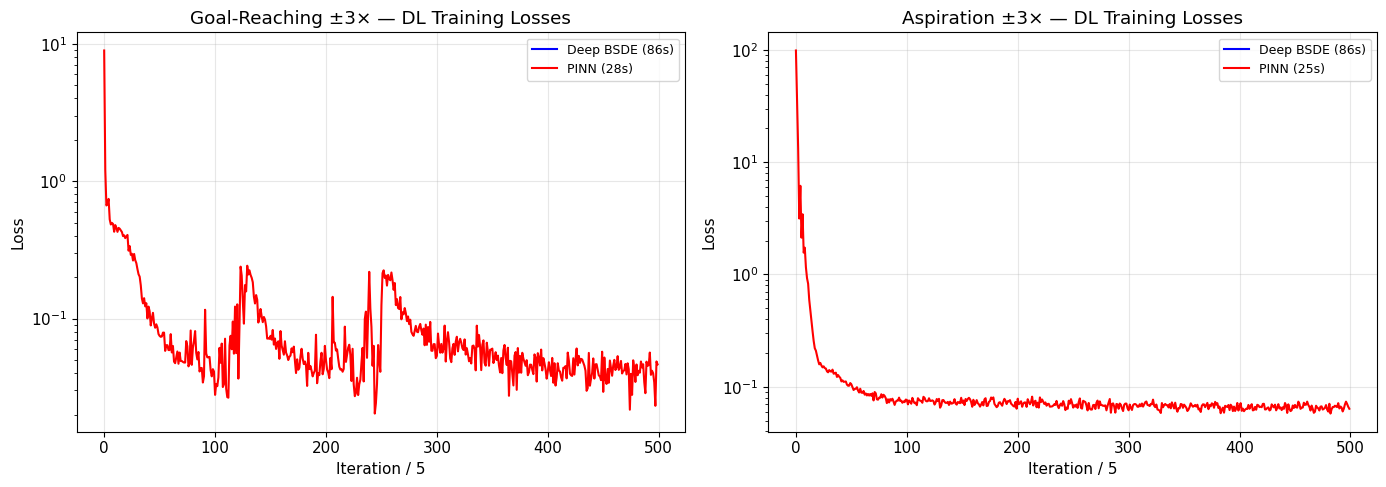

In [42]:
# Training-loss plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]; ax.set_title('Goal-Reaching ±3× — DL Training Losses')
ax.semilogy(bsde_lev_g_losses[::5], 'b-',  lw=1.5, label=f'Deep BSDE ({t_bsde_lg:.0f}s)')
ax.semilogy(pinn_lg_losses[::5],    'r-',  lw=1.5, label=f'PINN ({t_pinn_lg:.0f}s)')
ax.set_xlabel('Iteration / 5'); ax.set_ylabel('Loss'); ax.legend(fontsize=9)

ax = axes[1]; ax.set_title('Aspiration ±3× — DL Training Losses')
ax.semilogy(bsde_lev_a_losses[::5], 'b-',  lw=1.5, label=f'Deep BSDE ({t_bsde_la:.0f}s)')
ax.semilogy(pinn_la_losses[::5],    'r-',  lw=1.5, label=f'PINN ({t_pinn_la:.0f}s)')
ax.set_xlabel('Iteration / 5'); ax.set_ylabel('Loss'); ax.legend(fontsize=9)

plt.tight_layout()

# Summary
rows = [
    ('Deep BSDE',       f'{t_bsde_lg:.0f}s', f'{t_bsde_la:.0f}s', '1500 iters',
     'Soft near jump; smooth approx struggles at π discontinuity'),
    ('PINN',            f'{t_pinn_lg:.0f}s',  f'{t_pinn_la:.0f}s', '2500 iters',
     'PDE residual; diffuse around goal; can miss sharp switch'),
    ('Actor-Critic RL', f'{t_ac_lg:.0f}s',    f'{t_ac_la:.0f}s',   '3000 eps',
     'Model-free; noisy; gradual transition; less stiff'),
    ('LSTM',            f'{t_lstm_lg:.0f}s',  f'{t_lstm_la:.0f}s', '60 epochs',
     'Supervised on FD; best at replicating sharp policy'),
    ('Transformer',     f'{t_tf_lg:.0f}s',    f'{t_tf_la:.0f}s',   '60 epochs',
     'Supervised on FD; similar to LSTM; slightly smoother'),
]
print(f"{'Method':<18} {'Goal':>6} {'Asp':>6} {'Iters':>12}  Observation (±3× leverage)")
print('-' * 90)
for r in rows:
    print(f"{r[0]:<18} {r[1]:>6} {r[2]:>6} {r[3]:>12}  {r[4]}")